# Clustering Energy Analysis

Thin runner notebook for LRK/xKV clustering comparisons across keys and values, with independent cells for each tensor and clustering axis.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import torch
from scipy.stats import kendalltau, pearsonr, spearmanr


def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "utils").is_dir():
            return path
    raise RuntimeError("Could not find repo root containing ./utils")


repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

from analysis.utils import (
    collect_alignment_diagnostics,
    collect_head_cka,
    collect_layer_cka,
    display_case_result,
    load_kv_dump,
    plot_alignment_centroid_delta,
    plot_alignment_tail_delta,
    plot_centroid_tail_delta,
    plot_head_cka_heatmaps,
    plot_layer_cka_heatmaps,
    plot_combined_relative_spectral_tails,
    run_analysis_case,
    summarize_alignment_diagnostics,
    summarize_head_cka,
    summarize_layer_cka,
)

%load_ext autoreload
%autoreload 2

/home/m84366023/miniconda3/envs/pem-llm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
kv_dump_path = (
    repo_root
    / "results/kv_dumps/meta-llama_Llama-3.1-8B-Instruct/niah_multiquery_raw_kv.pt"
)
loaded = load_kv_dump(kv_dump_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

raw_keys = loaded["raw_keys"]
keys = loaded["keys"].to(device)
values = loaded["values"].to(device)
prompt_len = loaded["prompt_len"]
rope_theta = loaded["rope_theta"]

keys.shape, values.shape, prompt_len, rope_theta

Using device: cuda


(torch.Size([32, 1, 8, 3770, 128]),
 torch.Size([32, 1, 8, 3770, 128]),
 3770,
 500000.0)

In [25]:
show_detail_tables = False
plot_font_size = 14
show_bound_error_difference = False

if show_bound_error_difference:
    plot_figsize = (12, 6)
else:
    plot_figsize = (12, 4)
combined_plot_figsize = (12, 5)
relative_spectral_plot_figsize = (12, 4)
spectral_plot_figsize = (12, 8)
combined_relative_spectral_plot_figsize = (12, 6)
keys_spectral_ylim = (0, 30)
values_spectral_ylim = (0, 100)

kmeans_cfg = {
    "n_clusters": 3,
    "kmeans_cluster_size": 64,
    "kmeans_n_iter": 64,
    "kmeans_init": "kmeans++",
    "kmeans_dtype": torch.float32,
}

decomposition_cfg = {
    "decomposition_method": "svd",
    "rank_selection": "comp_ratio",
    "comp_ratio": 4,
    "energy_threshold": 0.95,
    "decomp_n_iter": 3,
    "decomp_lr": 1e-2,
}

lrk_mode = "per_head"  # "avg_heads" or "per_head"
include_lrk_head_breakdown = False
prefix_end = prompt_len
local_window = 0

xkv_layer_group_size = 4
xkv_num_layers = keys.size(0)


def save_case_figures(figures, case_name):
    plot_names = (
        "lrk_heads",
        "lrk_layers",
        "xkv_groups",
        "lrk_heads_xkv_groups",
        "spectral_tails_relative",
        "spectral_tails",
    )
    for figure, plot_name in zip(figures, plot_names, strict=True):
        if figure is None:
            continue
        save_path = f"plots/clustering_bounds_{case_name}_{plot_name}.svg"
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        figure.savefig(save_path, bbox_inches="tight", dpi=300)


def print_bound_error_correlations(case_result):
    metric_sets = (
        (
            "LRK clustered",
            case_result["lrk_results"],
            "head",
            ("layer_idx", "head_idx"),
        ),
        (
            "LRK unclustered",
            case_result["lrk_results_n1"],
            "head",
            ("layer_idx", "head_idx"),
        ),
        (
            "xKV clustered",
            case_result["xkv_results"],
            "group",
            ("group_start_layer", "group_last_layer"),
        ),
        (
            "xKV unclustered",
            case_result["xkv_results_n1"],
            "group",
            ("group_start_layer", "group_last_layer"),
        ),
    )

    print("Bound/error correlations:")
    for label, records, metric_scope, group_columns in metric_sets:
        df = pd.DataFrame(records)
        df = df[df["metric_scope"].eq(metric_scope)].copy()
        df["bound"] = df["eta"].clip(lower=0.0).pow(0.5)
        df = df.groupby(list(group_columns), as_index=False).agg(
            bound=("bound", "mean"),
            error=("relative_low_rank_recon_error", "mean"),
        )
        pearson = pearsonr(df["bound"], df["error"]).statistic
        spearman = spearmanr(df["bound"], df["error"]).statistic
        kendall = kendalltau(df["bound"], df["error"]).statistic
        print(
            f"  {label}: Pearson={pearson:.4f}, "
            f"Spearman={spearman:.4f}, Kendall={kendall:.4f}"
        )

## Keys, Row Clustering

In [26]:
keys_rows = run_analysis_case(
    keys,
    tensor_name="keys",
    cluster_axis="rows",
    kmeans_cfg=kmeans_cfg,
    decomposition_cfg=decomposition_cfg,
    lrk_mode=lrk_mode,
    include_lrk_head_breakdown=include_lrk_head_breakdown,
    prefix_end=prefix_end,
    local_window=local_window,
    xkv_layer_group_size=xkv_layer_group_size,
    xkv_num_layers=xkv_num_layers,
)

/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (1, 128). Using rank 1.
  warnings.warn(
/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (2, 128). Using rank 1.
  warnings.warn(


Bound/error correlations:
  LRK clustered: Pearson=0.9516, Spearman=0.9627, Kendall=0.8345
  LRK unclustered: Pearson=0.7189, Spearman=0.7950, Kendall=0.5977
  xKV clustered: Pearson=0.9406, Spearman=0.9286, Kendall=0.7857
  xKV unclustered: Pearson=0.8763, Spearman=0.8571, Kendall=0.7143


,case,rows,mean_eta,median_eta,mean_relative_low_rank_recon_error,median_relative_low_rank_recon_error,min_eta,max_eta
0,keys_lrk_rows,256,0.167389,0.161922,0.230501,0.237824,0.017658,0.370813
1,keys_xkv_rows,40,0.178437,0.183016,0.222188,0.227924,0.068934,0.268092
2,keys_lrk_rows_n_clusters_1,256,0.315142,0.304667,0.251843,0.258953,0.074367,0.558442
3,keys_xkv_rows_n_clusters_1,40,0.311980,0.306936,0.121584,0.123666,0.173713,0.473684


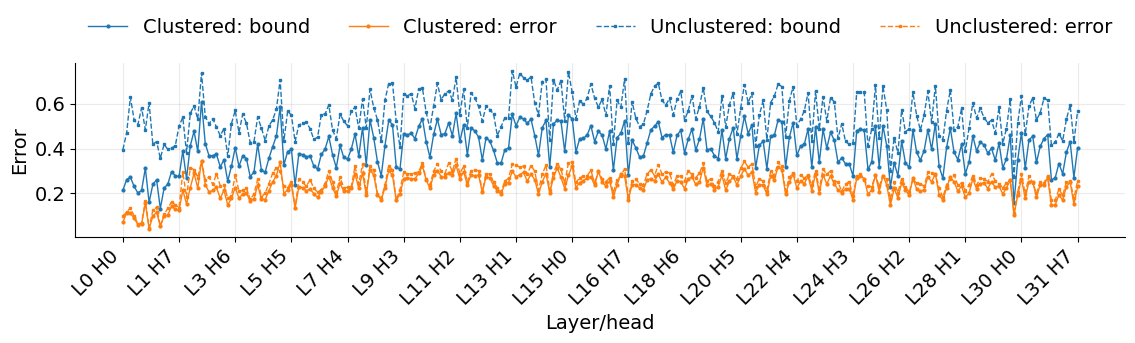

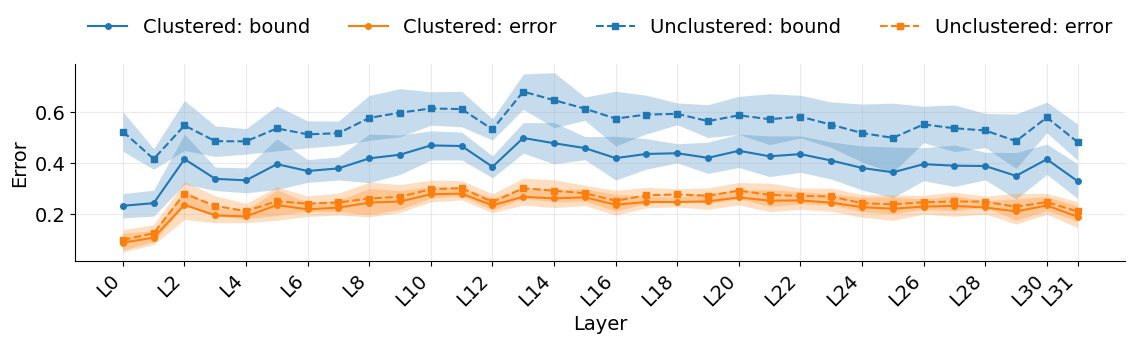

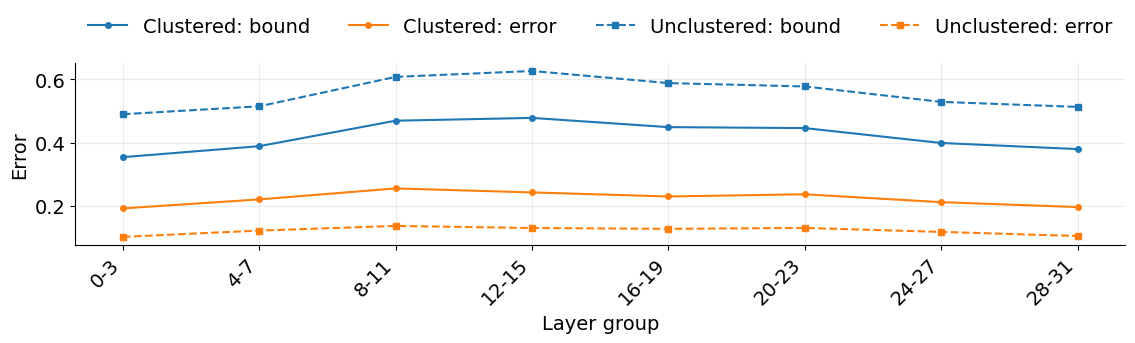

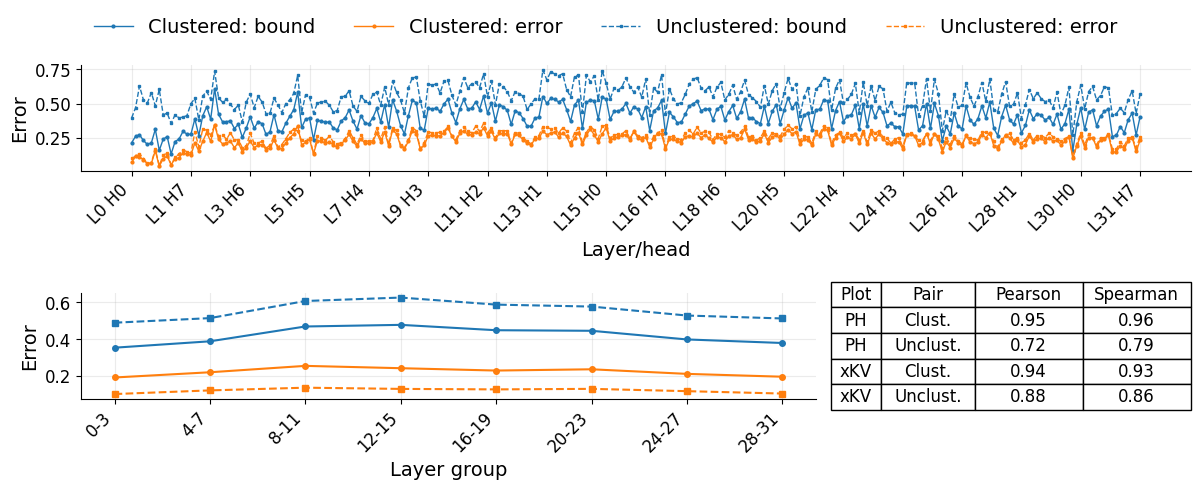

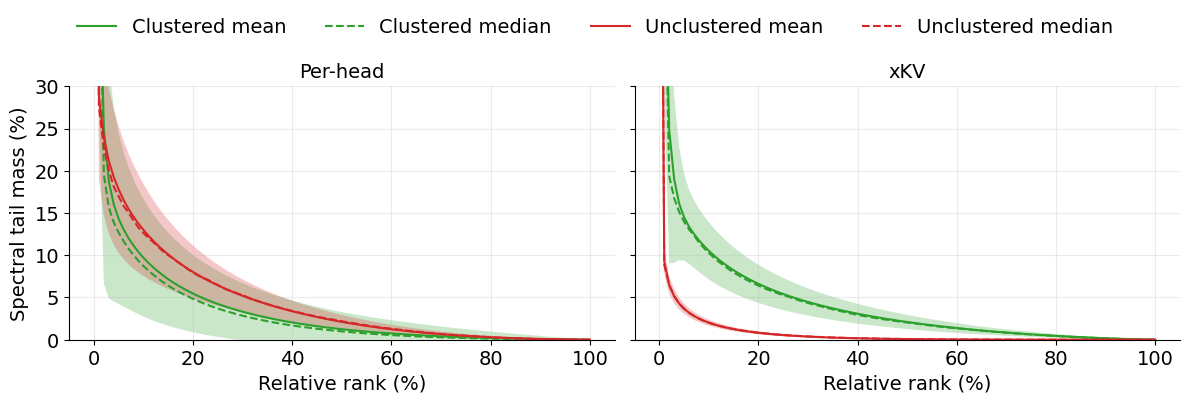

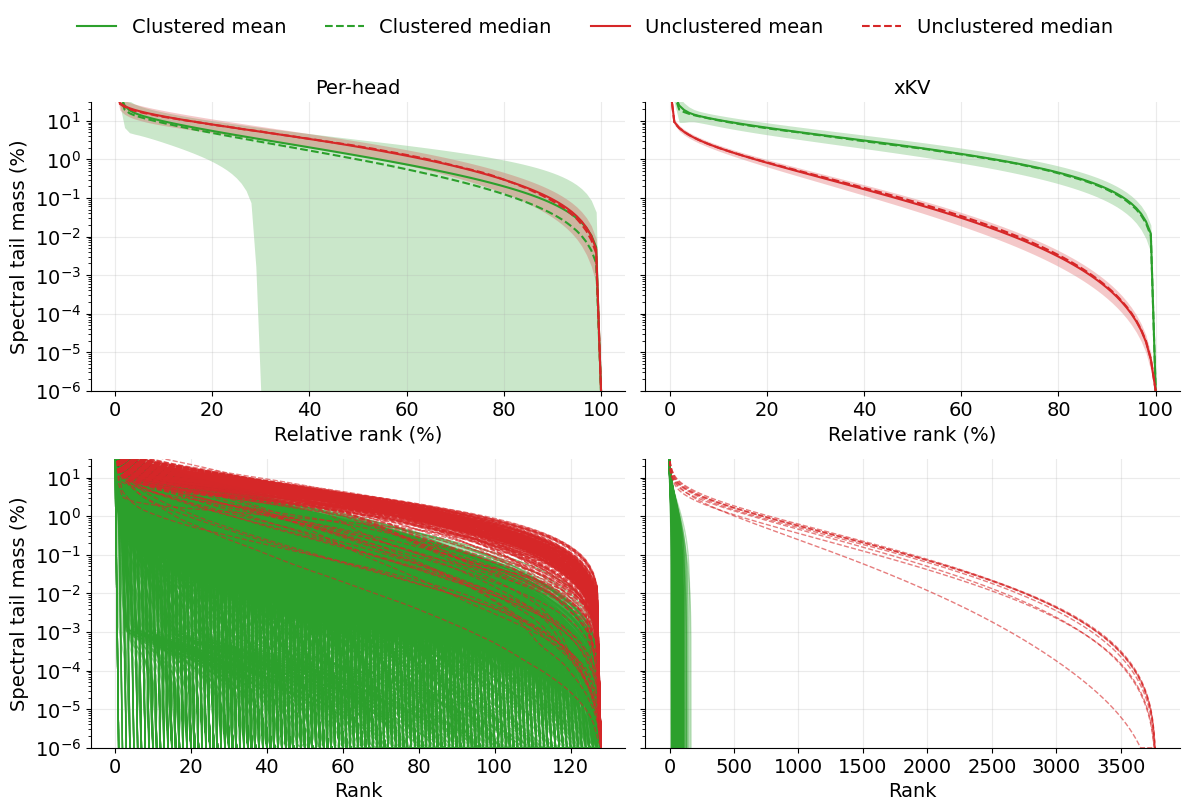

In [ ]:
print_bound_error_correlations(keys_rows)
keys_row_figures = display_case_result(
    keys_rows,
    show_detail_tables=show_detail_tables,
    plot_font_size=plot_font_size,
    plot_figsize=plot_figsize,
    combined_plot_figsize=combined_plot_figsize,
    relative_spectral_plot_figsize=relative_spectral_plot_figsize,
    spectral_plot_figsize=spectral_plot_figsize,
    spectral_ylim=keys_spectral_ylim,
    show_bound_error_difference=show_bound_error_difference,
)
save_case_figures(keys_row_figures, keys_rows["case_name"])

## Values, Row Clustering

In [17]:
values_rows = run_analysis_case(
    values,
    tensor_name="values",
    cluster_axis="rows",
    kmeans_cfg=kmeans_cfg,
    decomposition_cfg=decomposition_cfg,
    lrk_mode=lrk_mode,
    include_lrk_head_breakdown=include_lrk_head_breakdown,
    prefix_end=prefix_end,
    local_window=local_window,
    xkv_layer_group_size=xkv_layer_group_size,
    xkv_num_layers=xkv_num_layers,
)

/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (2, 128). Using rank 1.
  warnings.warn(
/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (1, 128). Using rank 1.
  warnings.warn(
/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (2, 4096). Using rank 1.
  warnings.warn(


Bound/error correlations:
  LRK clustered: Pearson=0.8000, Spearman=0.8066, Kendall=0.6180
  LRK unclustered: Pearson=0.7594, Spearman=0.7277, Kendall=0.5448
  xKV clustered: Pearson=0.7237, Spearman=0.9048, Kendall=0.7857
  xKV unclustered: Pearson=0.6190, Spearman=0.6429, Kendall=0.5000


,case,rows,mean_eta,median_eta,mean_relative_low_rank_recon_error,median_relative_low_rank_recon_error,min_eta,max_eta
0,values_lrk_rows,256,0.783919,0.812132,0.566958,0.572200,0.139031,0.951220
1,values_xkv_rows,40,0.812143,0.830848,0.423660,0.429406,0.466837,0.888889
2,values_lrk_rows_n_clusters_1,256,0.891137,0.922806,0.631394,0.642685,0.213010,0.988571
3,values_xkv_rows_n_clusters_1,40,0.883943,0.905339,0.358285,0.353400,0.528061,0.944751


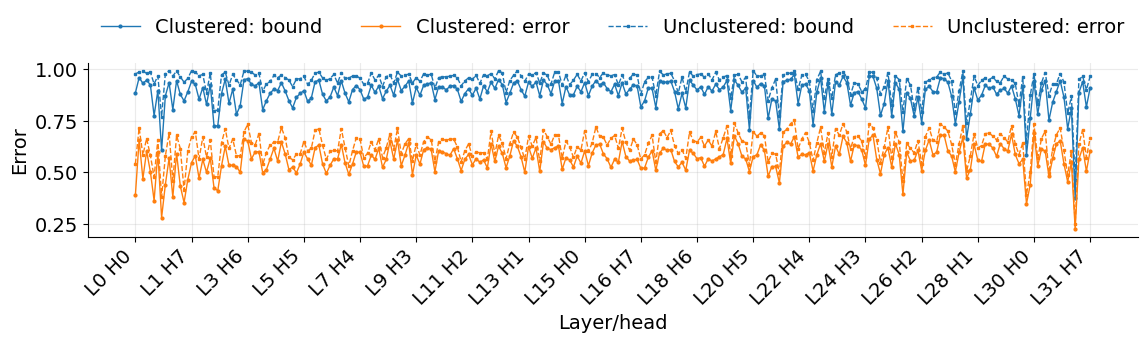

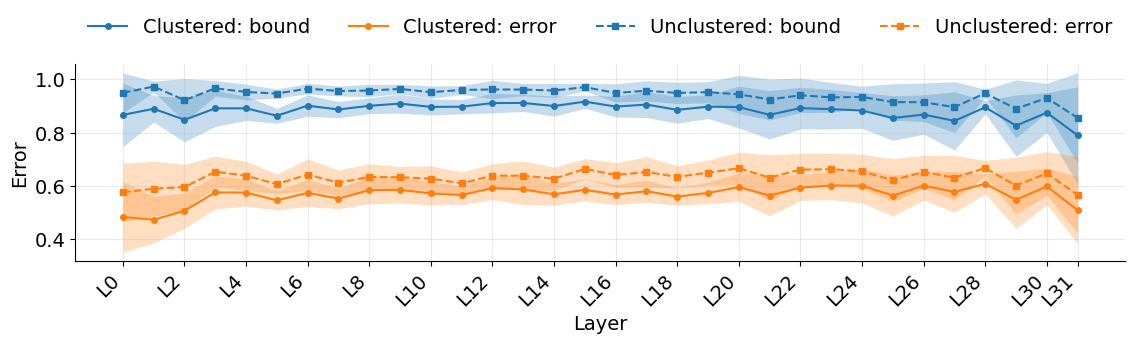

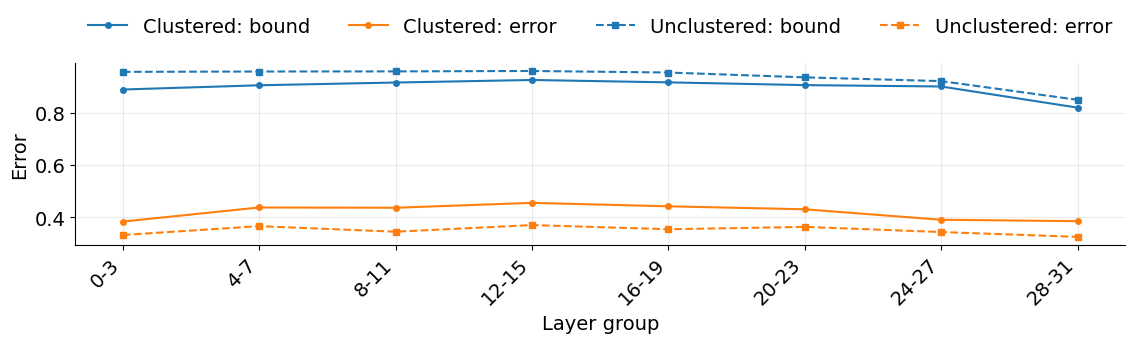

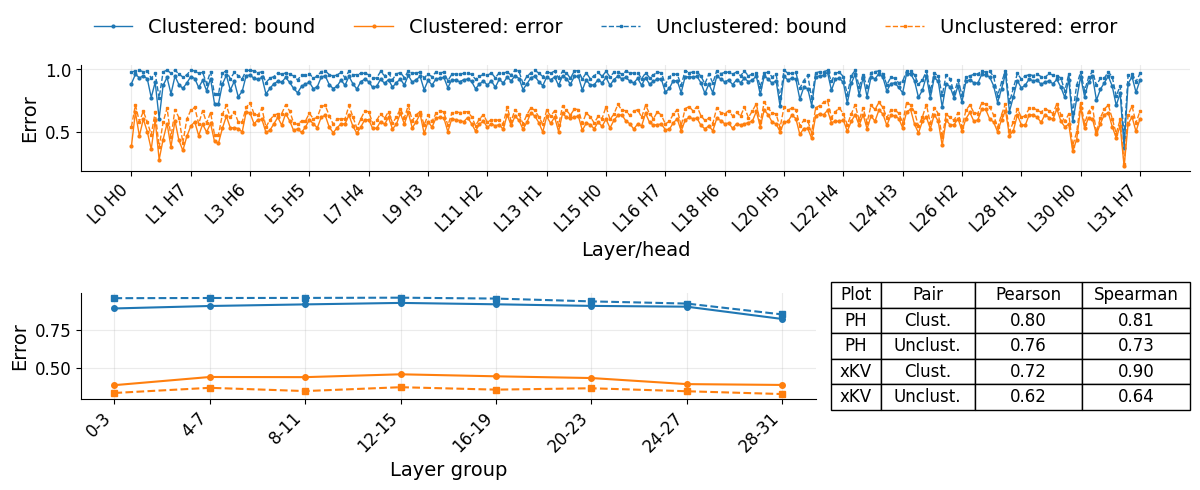

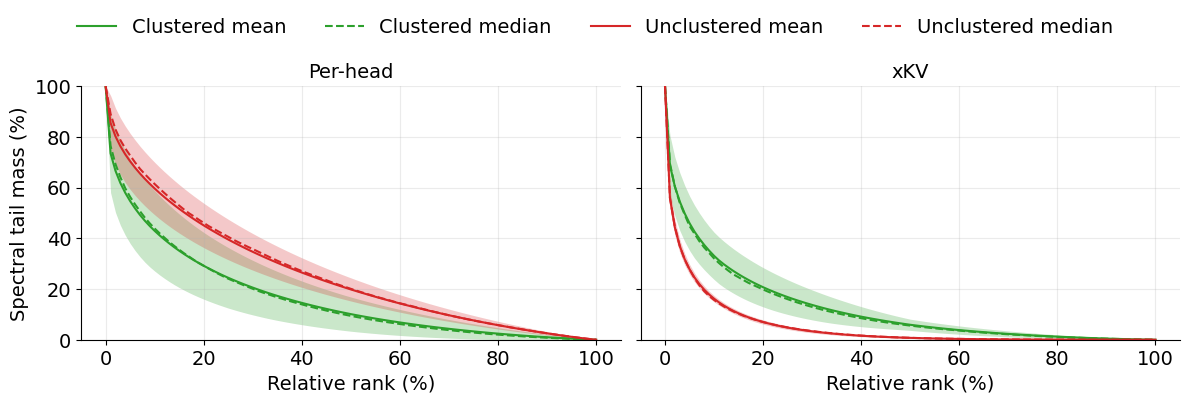

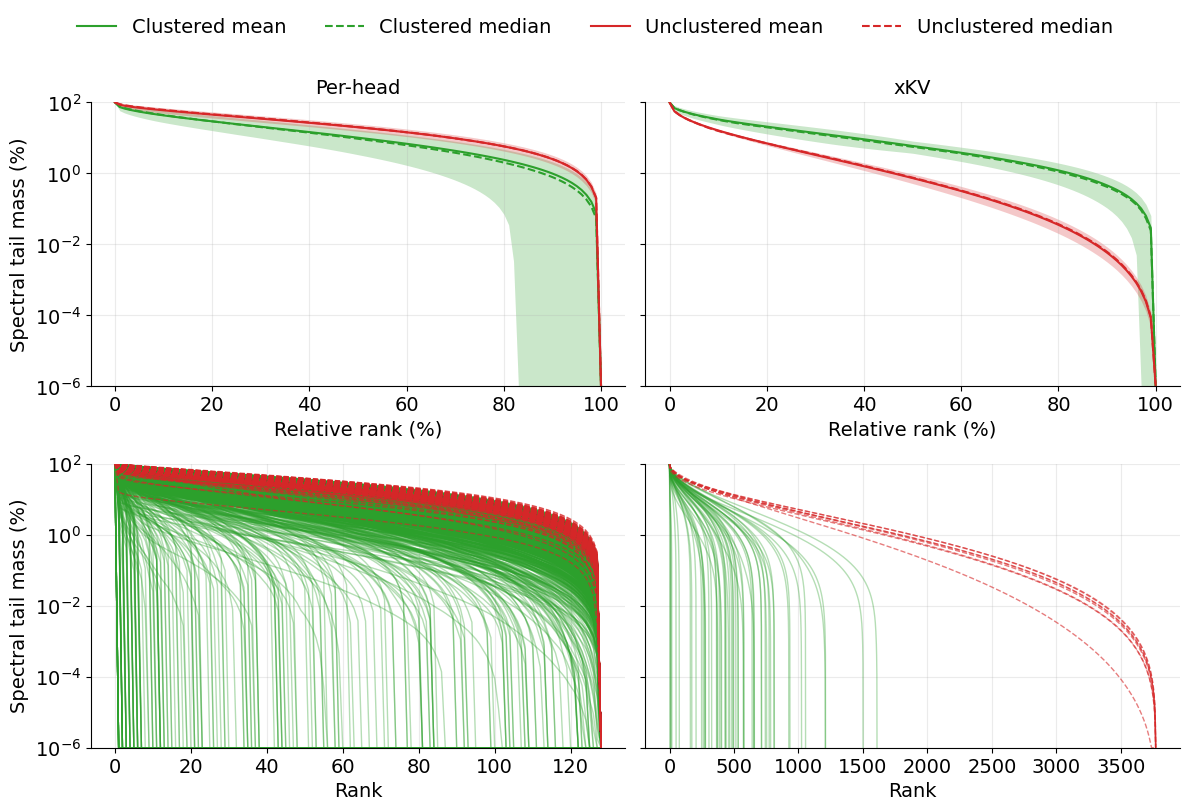

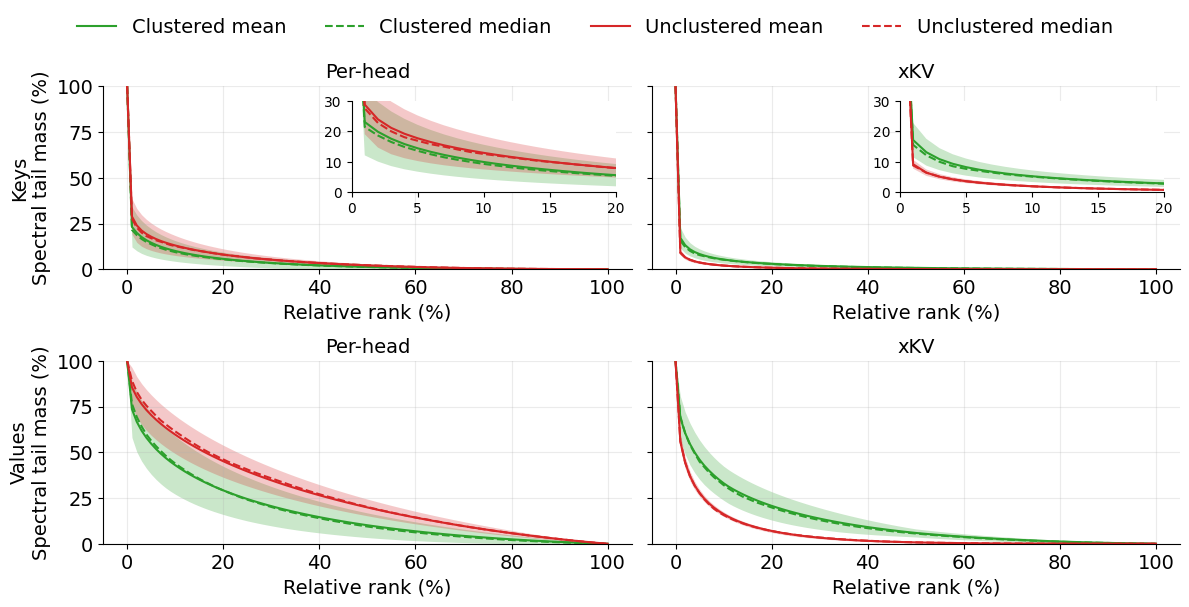

In [18]:
print_bound_error_correlations(values_rows)
values_row_figures = display_case_result(
    values_rows,
    show_detail_tables=show_detail_tables,
    plot_font_size=plot_font_size,
    plot_figsize=plot_figsize,
    combined_plot_figsize=combined_plot_figsize,
    relative_spectral_plot_figsize=relative_spectral_plot_figsize,
    spectral_plot_figsize=spectral_plot_figsize,
    spectral_ylim=values_spectral_ylim,
    show_bound_error_difference=show_bound_error_difference,
)
save_case_figures(values_row_figures, values_rows["case_name"])

combined_relative_spectral_figure = plot_combined_relative_spectral_tails(
    keys_rows,
    values_rows,
    font_size=plot_font_size,
    figsize=combined_relative_spectral_plot_figsize,
    values_ylim=values_spectral_ylim,
)
if combined_relative_spectral_figure is not None:
    combined_relative_spectral_figure.savefig(
        "plots/clustering_bounds_keys_values_spectral_tails_relative.svg",
        bbox_inches="tight",
        dpi=300,
    )

# Alignment diagnostics

• A_align is always a weighted average of pairwise subspace overlap:

  A_ij = ||V_i^T V_j||_F^2 / r

  where V_i and V_j are the top right-singular-vector bases of centered matrices. So it measures how similar
  the feature-space low-rank bases are, not whether token rows are close in Euclidean distance.

  In the table:

  cluster_partition / per_head / K
  For each layer and KV head, X = keys[layer, head] with shape [T, d_head]. K-means partitions token rows.
  A_align measures whether the token clusters inside that one key head share the same right-singular feature
  basis. Aggregated across all layer/head rows.

  cluster_partition / per_head / V
  Same as above, but using values[layer, head]. It measures subspace sharing across value-token clusters
  inside each layer/head.

  cluster_partition / xkv / K
  For each xKV layer group, the code builds one matrix by concatenating grouped key layers and heads on the
  feature axis, roughly [T, group_size * H * d_head]. K-means partitions token rows of that xKV matrix.
  A_align measures whether those xKV token clusters share the same large feature-space basis.

  cluster_partition / xkv / V
  Same as xKV/K, but using values.

  cross_layer_pooling / xkv_layer_matrix / K
  This does not use k-means clusters. For each layer group, it builds one matrix per layer: [T, H * d_head].
  A_align measures how aligned the pooled key-layer subspaces are across layers in the group. This diagnoses
  whether xKV pooling across layers is sensible.

  cross_layer_pooling / xkv_layer_matrix / V
  Same, but for value layer matrices.

  cross_layer_pooling / xkv_same_head / K
  For each layer group and each head, it compares [T, d_head] key matrices for the same head index across
  layers. This is the stricter “same head across layers” alignment.

  cross_layer_pooling / xkv_same_head / V
  Same, but for values.

  Aggregation:
  Within one diagnostic row, pairwise A_ij values are weighted by matrix row counts: T_i * T_j. For k-means
  clusters, that means larger cluster pairs contribute more. The summary table then reports simple mean/
  median over rows in alignment_df, grouped by diagnostic, scope, and cache. So per-head rows are averaged
  over layer/head instances; xKV rows over layer groups; same-head rows over layer-group/head instances.


In [8]:
alignment_comp_ratio = decomposition_cfg["comp_ratio"]
alignment_df = collect_alignment_diagnostics(
    {"K": keys, "V": values},
    kmeans_cfg=kmeans_cfg,
    comp_ratio=alignment_comp_ratio,
    layer_group_size=xkv_layer_group_size,
    num_layers=xkv_num_layers,
    prefix_end=prefix_end,
    local_window=local_window,
)


/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (1, 128). Using rank 1.
  warnings.warn(
/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (2, 128). Using rank 1.
  warnings.warn(
/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (2, 4096). Using rank 1.
  warnings.warn(


,diagnostic,scope,cache,n,A_align_mean,A_align_median,B_sep_mean,B_sep_median,delta_tail_mean,delta_tail_median
0,cluster_partition,per_head,K,256,0.582315,0.585497,0.269906,0.252062,0.011886,0.011360
1,cluster_partition,per_head,V,256,0.398036,0.393895,0.117140,0.107836,0.074178,0.069257
2,cluster_partition,xkv,K,8,0.385199,0.378096,0.234836,0.229735,-0.010104,-0.009402
3,cluster_partition,xkv,V,8,0.347473,0.345084,0.077571,0.071545,-0.061376,-0.059315
4,cross_layer_pooling,xkv_layer_matrix,K,8,0.236327,0.233671,NaN,NaN,NaN,NaN
5,cross_layer_pooling,xkv_layer_matrix,V,8,0.202334,0.202133,NaN,NaN,NaN,NaN
6,cross_layer_pooling,xkv_same_head,K,64,0.318880,0.308015,NaN,NaN,NaN,NaN
7,cross_layer_pooling,xkv_same_head,V,64,0.241519,0.241786,NaN,NaN,NaN,NaN


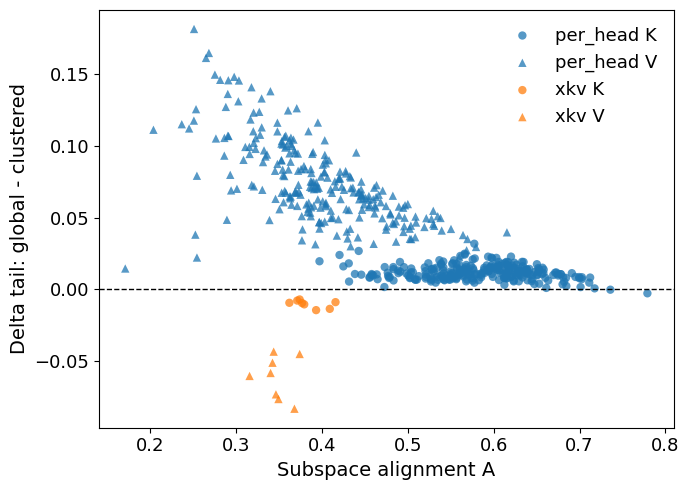

In [9]:
alignment_summary = summarize_alignment_diagnostics(alignment_df)

display(alignment_summary)

alignment_plot = plot_alignment_tail_delta(
    alignment_df,
    figsize=(7, 5),
    font_size=plot_font_size,
)
os.makedirs("plots", exist_ok=True)
alignment_plot.savefig(
    "plots/clustering_alignment_tail_delta.svg",
    bbox_inches="tight",
    dpi=300,
)

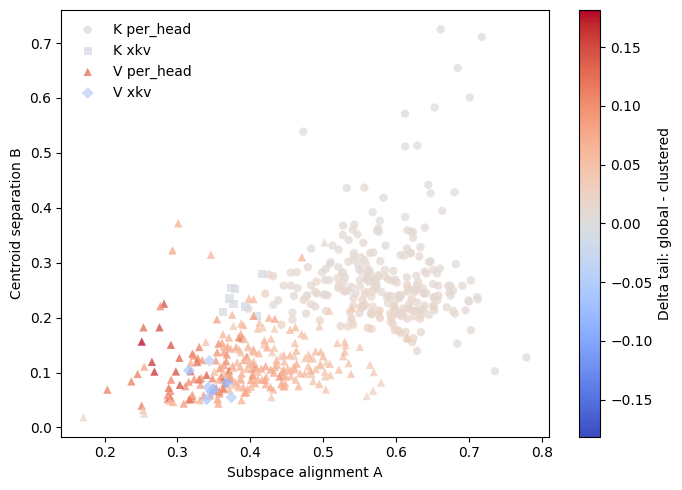

In [10]:
alignment_centroid_plot = plot_alignment_centroid_delta(alignment_df, figsize=(7, 5))
alignment_centroid_plot.savefig(
    "plots/clustering_alignment_centroid_delta.svg",
    bbox_inches="tight",
    dpi=300,
)


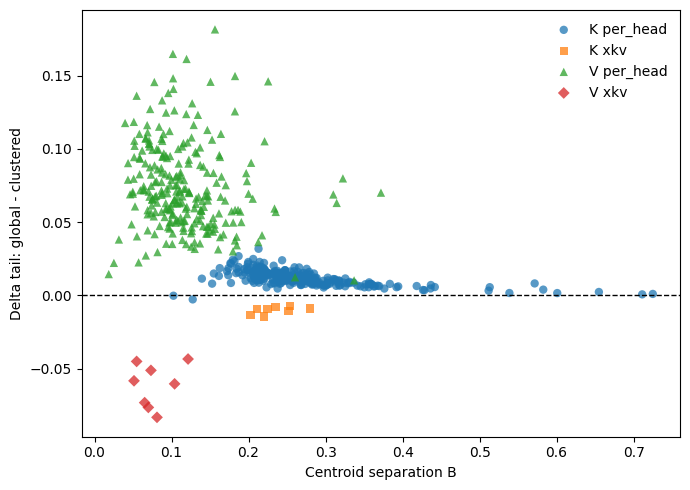

In [11]:
centroid_tail_plot = plot_centroid_tail_delta(alignment_df, figsize=(7, 5))
centroid_tail_plot.savefig(
    "plots/clustering_centroid_tail_delta.svg",
    bbox_inches="tight",
    dpi=300,
)


,cache,setting,n_pairs,CKA_mean,CKA_std
0,K,same layer,896,0.787174,0.103686
1,K,same xKV group,3968,0.763530,0.114118
2,K,"same head index, same xKV group",384,0.757957,0.119424
3,K,all heads,32640,0.681789,0.129724
4,K,same head index,3968,0.679936,0.129250
5,K,different layer,31744,0.678814,0.129142
6,K,"same head index, different xKV group",3584,0.671577,0.127457
7,K,different xKV group,28672,0.670476,0.127680
8,V,same layer,896,0.349649,0.159305
9,V,same xKV group,3968,0.334177,0.146709


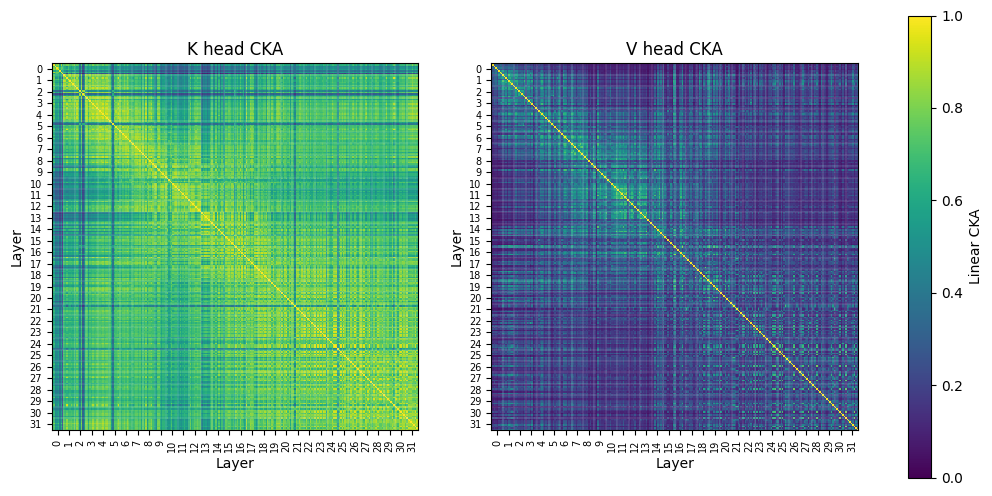

In [12]:
head_cka_by_cache, head_labels, cka_num_layers, cka_num_heads = collect_head_cka(
    {"K": keys, "V": values},
    prefix_end=prefix_end,
    local_window=local_window,
)

display(summarize_head_cka(
    head_cka_by_cache,
    num_layers=cka_num_layers,
    num_heads=cka_num_heads,
    layer_group_size=xkv_layer_group_size,
    sort_by_cka_mean=True,
))

head_cka_figure = plot_head_cka_heatmaps(
    head_cka_by_cache,
    num_layers=cka_num_layers,
    num_heads=cka_num_heads,
)
os.makedirs("plots", exist_ok=True)
head_cka_figure.savefig("plots/cka_pairwise_heads.svg", bbox_inches="tight", dpi=300)


,cache,setting,n_pairs,CKA_mean,CKA_std
0,K,same xKV group,48,0.927761,0.067066
1,K,all layers,496,0.825246,0.113014
2,K,different xKV group,448,0.814262,0.111409
3,V,same xKV group,48,0.759325,0.055573
4,V,all layers,496,0.566536,0.145175
5,V,different xKV group,448,0.545880,0.136360


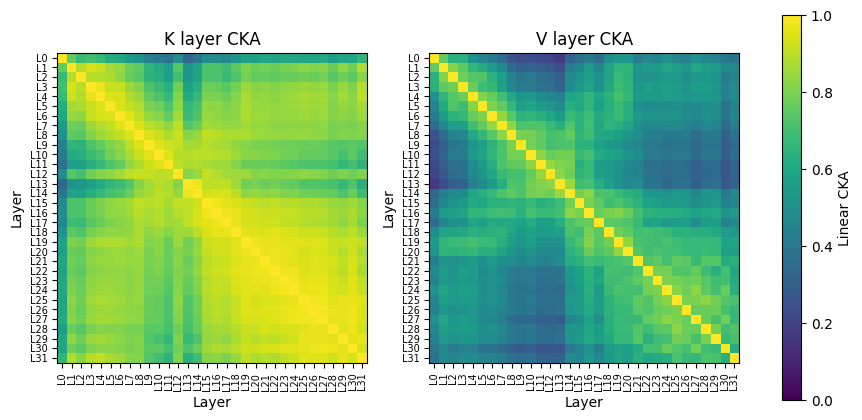

In [13]:
layer_cka_by_cache, layer_labels = collect_layer_cka(
    {"K": keys, "V": values},
    prefix_end=prefix_end,
    local_window=local_window,
)

display(summarize_layer_cka(
    layer_cka_by_cache,
    num_layers=len(layer_labels),
    layer_group_size=xkv_layer_group_size,
    sort_by_cka_mean=True,
))

layer_cka_figure = plot_layer_cka_heatmaps(layer_cka_by_cache, layer_labels=layer_labels)
os.makedirs("plots", exist_ok=True)
layer_cka_figure.savefig("plots/cka_pairwise_layers.svg", bbox_inches="tight", dpi=300)
